## Librerias

In [34]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import pearsonr, spearmanr, chi2_contingency


from sklearn.preprocessing import PowerTransformer

from sklearn.feature_selection import mutual_info_classif

Lectura de los datos

In [11]:
df_raw = pd.read_csv("../data/framingham.csv")

In [12]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4240 entries, 0 to 4239
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   male             4240 non-null   int64  
 1   age              4240 non-null   int64  
 2   education        4135 non-null   float64
 3   currentSmoker    4240 non-null   int64  
 4   cigsPerDay       4211 non-null   float64
 5   BPMeds           4187 non-null   float64
 6   prevalentStroke  4240 non-null   int64  
 7   prevalentHyp     4240 non-null   int64  
 8   diabetes         4240 non-null   int64  
 9   totChol          4190 non-null   float64
 10  sysBP            4240 non-null   float64
 11  diaBP            4240 non-null   float64
 12  BMI              4221 non-null   float64
 13  heartRate        4239 non-null   float64
 14  glucose          3852 non-null   float64
 15  TenYearCHD       4240 non-null   int64  
dtypes: float64(9), int64(7)
memory usage: 530.1 KB


In [13]:
df_raw.shape

(4240, 16)

In [14]:
df_raw.head(7)

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0
5,0,43,2.0,0,0.0,0.0,0,1,0,228.0,180.0,110.0,30.30,77.0,99.0,0
6,0,63,1.0,0,0.0,0.0,0,0,0,205.0,138.0,71.0,33.11,60.0,85.0,1


In [15]:
#Comprobamos cuantos nulos tiene
df_raw.isnull().sum()

male                 0
age                  0
education          105
currentSmoker        0
cigsPerDay          29
BPMeds              53
prevalentStroke      0
prevalentHyp         0
diabetes             0
totChol             50
sysBP                0
diaBP                0
BMI                 19
heartRate            1
glucose            388
TenYearCHD           0
dtype: int64

Antes de empezar con el EDA, voy a declarar las variables que están codificadas como categóricas, para que tenga sentido las gráficas.

In [18]:
df= df_raw.copy()
categoricas = ['male', 'education', 'currentSmoker', 'BPMeds', 'prevalentStroke', 'prevalentHyp', 'diabetes', 'TenYearCHD']
df[categoricas] = df[categoricas].astype('object')

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4240 entries, 0 to 4239
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   male             4240 non-null   object 
 1   age              4240 non-null   int64  
 2   education        4135 non-null   object 
 3   currentSmoker    4240 non-null   object 
 4   cigsPerDay       4211 non-null   float64
 5   BPMeds           4187 non-null   object 
 6   prevalentStroke  4240 non-null   object 
 7   prevalentHyp     4240 non-null   object 
 8   diabetes         4240 non-null   object 
 9   totChol          4190 non-null   float64
 10  sysBP            4240 non-null   float64
 11  diaBP            4240 non-null   float64
 12  BMI              4221 non-null   float64
 13  heartRate        4239 non-null   float64
 14  glucose          3852 non-null   float64
 15  TenYearCHD       4240 non-null   object 
dtypes: float64(7), int64(1), object(8)
memory usage: 530.1+ KB


In [31]:
numeric_cols = df.select_dtypes(exclude= 'object').columns.tolist()
categoric_cols = df.select_dtypes(include ='object').columns.tolist()
print(numeric_cols)
print("-----------------")
print(categoric_cols)

['age', 'cigsPerDay', 'totChol', 'sysBP', 'diaBP', 'BMI', 'heartRate', 'glucose']
-----------------
['male', 'education', 'currentSmoker', 'BPMeds', 'prevalentStroke', 'prevalentHyp', 'diabetes', 'TenYearCHD']


Vamo a ver los estadísticos principales, para ver como primera interacción los datos. Podemos observar: que posiblemente haya outliers en las siguientes columnas (totChol, diaBP,sispBP ,hearRate y glucose,etc).

In [23]:
df.describe(percentiles=[.25,.5,.75,.95,.99]).T

,count,mean,std,min,25%,50%,75%,95%,99%,max
age,4240.0,49.580189,8.572942,32.00,42.00,49.0,56.00,64.000,67.000,70.0
cigsPerDay,4211.0,9.005937,11.922462,0.00,0.00,0.0,20.00,30.000,43.000,70.0
totChol,4190.0,236.699523,44.591284,107.00,206.00,234.0,263.00,312.000,354.110,696.0
sysBP,4240.0,132.354599,22.033300,83.50,117.00,128.0,144.00,175.000,200.000,295.0
diaBP,4240.0,82.897759,11.910394,48.00,75.00,82.0,90.00,104.525,118.000,142.5
BMI,4221.0,25.800801,4.079840,15.54,23.07,25.4,28.04,32.780,38.956,56.8
heartRate,4239.0,75.878981,12.025348,44.00,68.00,75.0,83.00,98.000,110.000,143.0
glucose,3852.0,81.963655,23.954335,40.00,71.00,78.0,87.00,108.450,174.960,394.0


In [33]:
#Ver estadísticos principales de cada variable, para saber cuantos valores únicos tienen, cual es el más frecuente, etc.
df.describe(include=object).T

,count,unique,top,freq
male,4240.0,2.0,0.0,2420.0
education,4135.0,4.0,1.0,1720.0
currentSmoker,4240.0,2.0,0.0,2145.0
BPMeds,4187.0,2.0,0.0,4063.0
prevalentStroke,4240.0,2.0,0.0,4215.0
prevalentHyp,4240.0,2.0,0.0,2923.0
diabetes,4240.0,2.0,0.0,4131.0
TenYearCHD,4240.0,2.0,0.0,3596.0


Vemos el peso que tienen en el dataset de si se ha desarrollado o no

In [30]:
df['TenYearCHD'].value_counts(normalize=True)*100

TenYearCHD
0    84.811321
1    15.188679
Name: proportion, dtype: float64

## Análisis Univariable

**Columnas Categóricas**

Observamos las distribuciones de cada una de las variables numéricas y a priori podemos ver que hay outliers como hemos dicho previamente y que las distribuciones parecen ser mas o menos normales, excepto en algunas variables como por ejemplo: cigsperDay. Pasos que voy a seguir:

1. **cigsperDay**: para normalizar su distribución podría probar con el método de BoxCox para ver si corrige un poco hacia la distribución normal. Y al ser todos los valores mayores que 0, creo que podríamos hacerlo.
2. **Tratamiento de los nulos** : En los nulos que no vemos de manera clara la distribución, vamos a implementar las siguientes estrategias:
- **glucose** la estrategia que vamos a implementar es la de transformarlo a logaritmo, para que los outliers tengan mucho menos impacto e intentar ver la distribución de manera más clara.

Observamos a primera vista que hay muchas columnas identificamos que tienen sesgo, ya que hay distribuciones que tienen una cola de outliers muy para la derecha. Por ejemplo: totChol, sysBP, BMI, heartrate,etc.


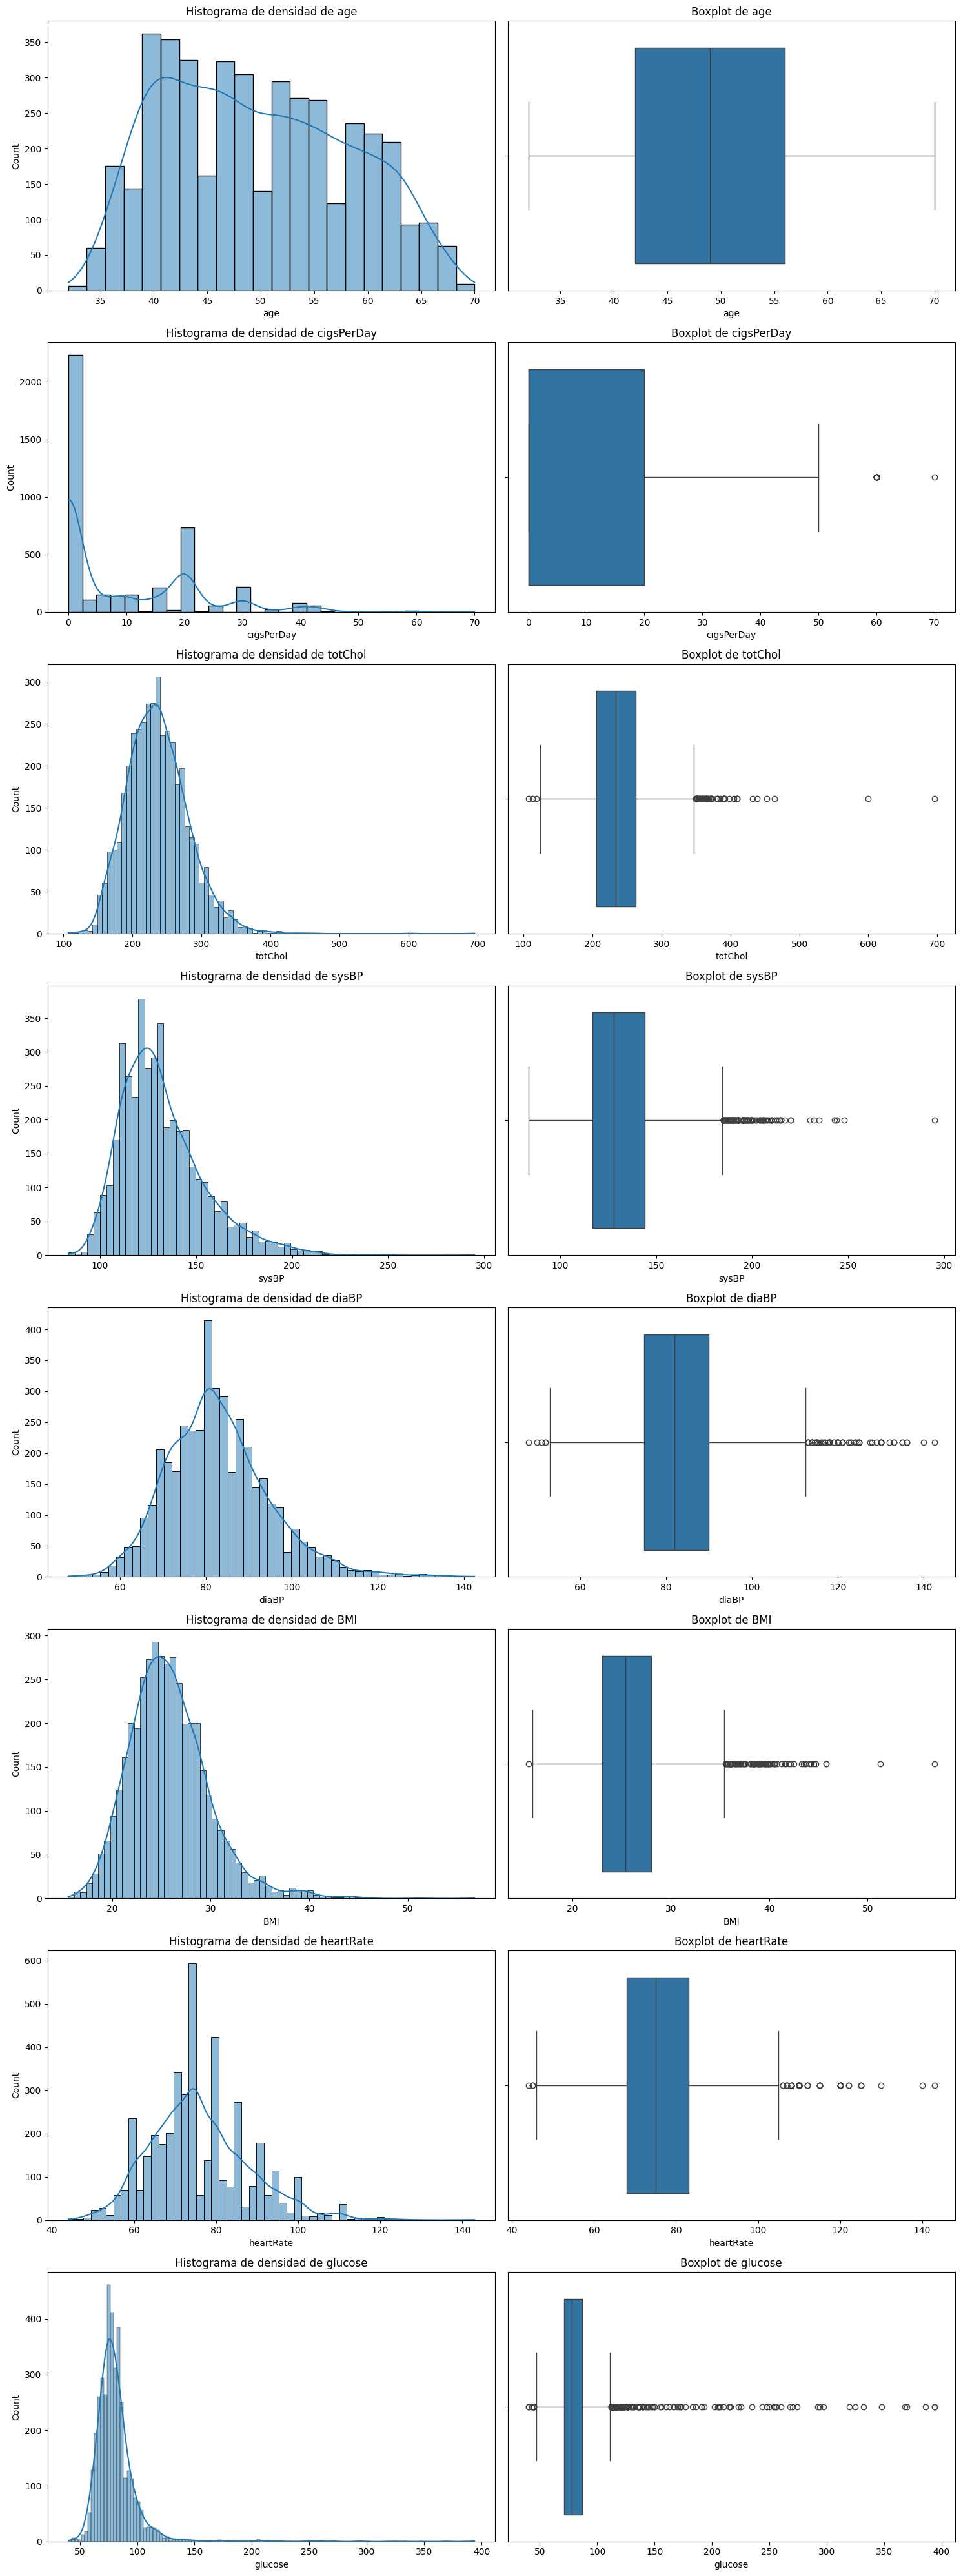

In [ ]:
nrows = len(numeric_cols)
fig, axes = plt.subplots(nrows= nrows, ncols=2, figsize=(15, 5*nrows))

for i, column in enumerate(df_raw[numeric_cols]):
    # i = índice (0,1,2,3,4)  | column es lo mismo solo que para usarlo de diferente manera.
    #Histograma de densidad
    sns.histplot(df_raw[column],kde = True, ax=axes[i,0]) 
        # kde=True --> Dibuja una linea sobre las barras que ayuda a ver la "forma" de los datos.
        # ax=axes[i,0] --> Dibuja el histograma en la fila i, columna 0 (la izquierda).
    axes[i, 0].set_title(f'Histograma de densidad de {column}')

    #Boxplot
    sns.boxplot(x=df_raw[column], ax=axes[i,1])
    axes[i,1].set_title(f"Boxplot de {column}")

plt.tight_layout()
plt.show()

Observamos el porcentaje de los outliers y observamos que no son muchos, por lo que algunas columnas en el que se vean bien la distirbución normal, no las vamos a tratar en el EDA.

In [37]:
print("--- Resumen de Outliers ---")
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    perc = (len(outliers) / len(df)) * 100
    print(f"{col}: {len(outliers)} registros ({perc:.2f}%)")

--- Resumen de Outliers ---
age: 0 registros (0.00%)
cigsPerDay: 12 registros (0.28%)
totChol: 56 registros (1.32%)
sysBP: 126 registros (2.97%)
diaBP: 77 registros (1.82%)
BMI: 97 registros (2.29%)
heartRate: 76 registros (1.79%)
glucose: 188 registros (4.43%)


**BoxCox**

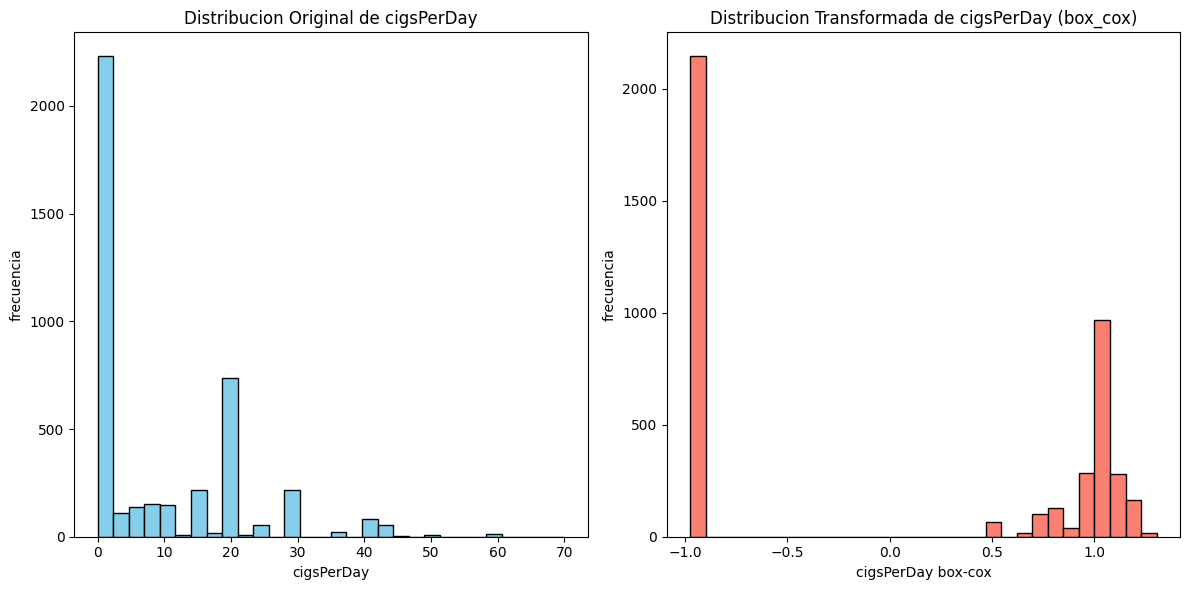

In [43]:
pt=PowerTransformer(method="box-cox")
df['cigsPerDay_Box']=pt.fit_transform(df[["cigsPerDay"]]+0.001) #el +0.001 porque necesitamos extrictamente valores positivos

plt.figure(figsize=(12,6))

#histograma de la distribucion original de "fare"
plt.subplot(1,2,1)
plt.hist(df['cigsPerDay'],bins=30,color="skyblue",edgecolor="k")
plt.title("Distribucion Original de cigsPerDay")
plt.xlabel("cigsPerDay")
plt.ylabel("frecuencia")

#histograma de la distribucion transformada de "fare_box-cox"
plt.subplot(1,2,2)
plt.hist(df['cigsPerDay_Box'],bins=30,color="salmon",edgecolor="k")
plt.title("Distribucion Transformada de cigsPerDay (box_cox)")
plt.xlabel("cigsPerDay box-cox")
plt.ylabel("frecuencia")

plt.tight_layout()
plt.show()

Aqui vemos claramente la brecha entre los que no fuman y los que fuman, ha normalizado a los que fuman, en cambio, es obvio que los que no fuman están alejados de la distribución normal y en este caso se puede ver claramente que los no fumadoores son la gran mayoría de las personas.

**Logaritmo**

In [39]:
df["glucose_log"]=np.log1p(df["glucose"])

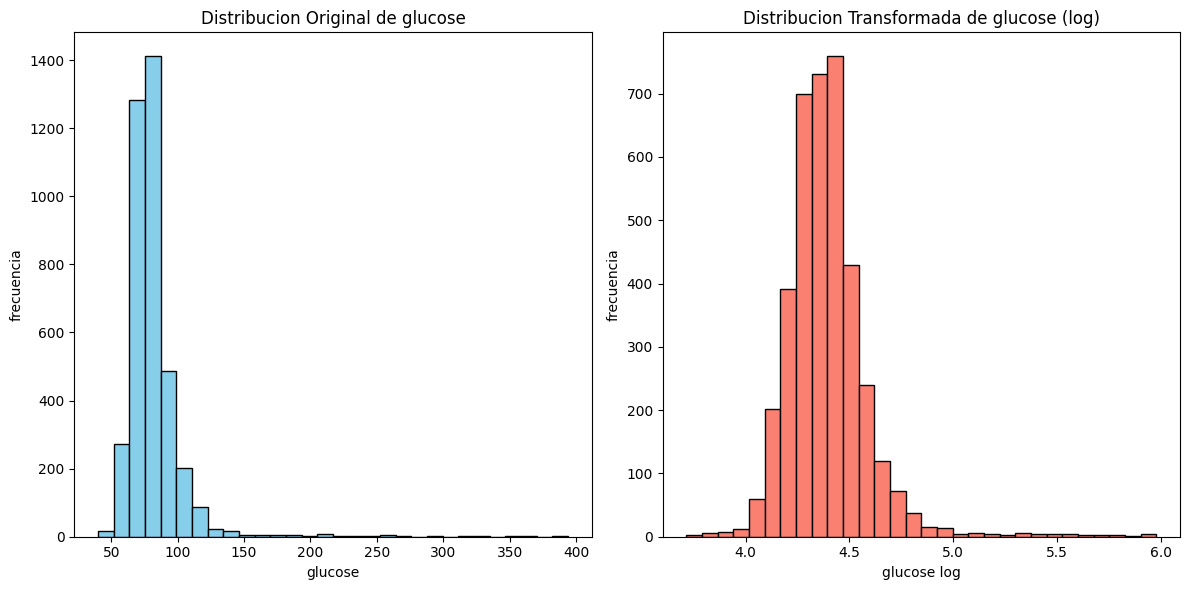

In [44]:
plt.figure(figsize=(12,6))

#histograma de la distribucion original de "fare"
plt.subplot(1,2,1)
plt.hist(df["glucose"],bins=30,color="skyblue",edgecolor="k")
plt.title("Distribucion Original de glucose")
plt.xlabel("glucose")
plt.ylabel("frecuencia")

#histograma de la distribucion transformada de "fare_robust"
plt.subplot(1,2,2)
plt.hist(df["glucose_log"],bins=30,color="salmon",edgecolor="k")
plt.title("Distribucion Transformada de glucose (log)")
plt.xlabel("glucose log")
plt.ylabel("frecuencia")

plt.tight_layout()
plt.show()

Observamos que ha mejorado la vista de la distribución y el logaritmo ha hecho que el impacto de los outliers sea mucho menor. Por lo que en el preprocessing se podría implementar el logaritmo.

Una vez hecho esto observamos el histograma y el boxplot de nuevo de estas dos variables.

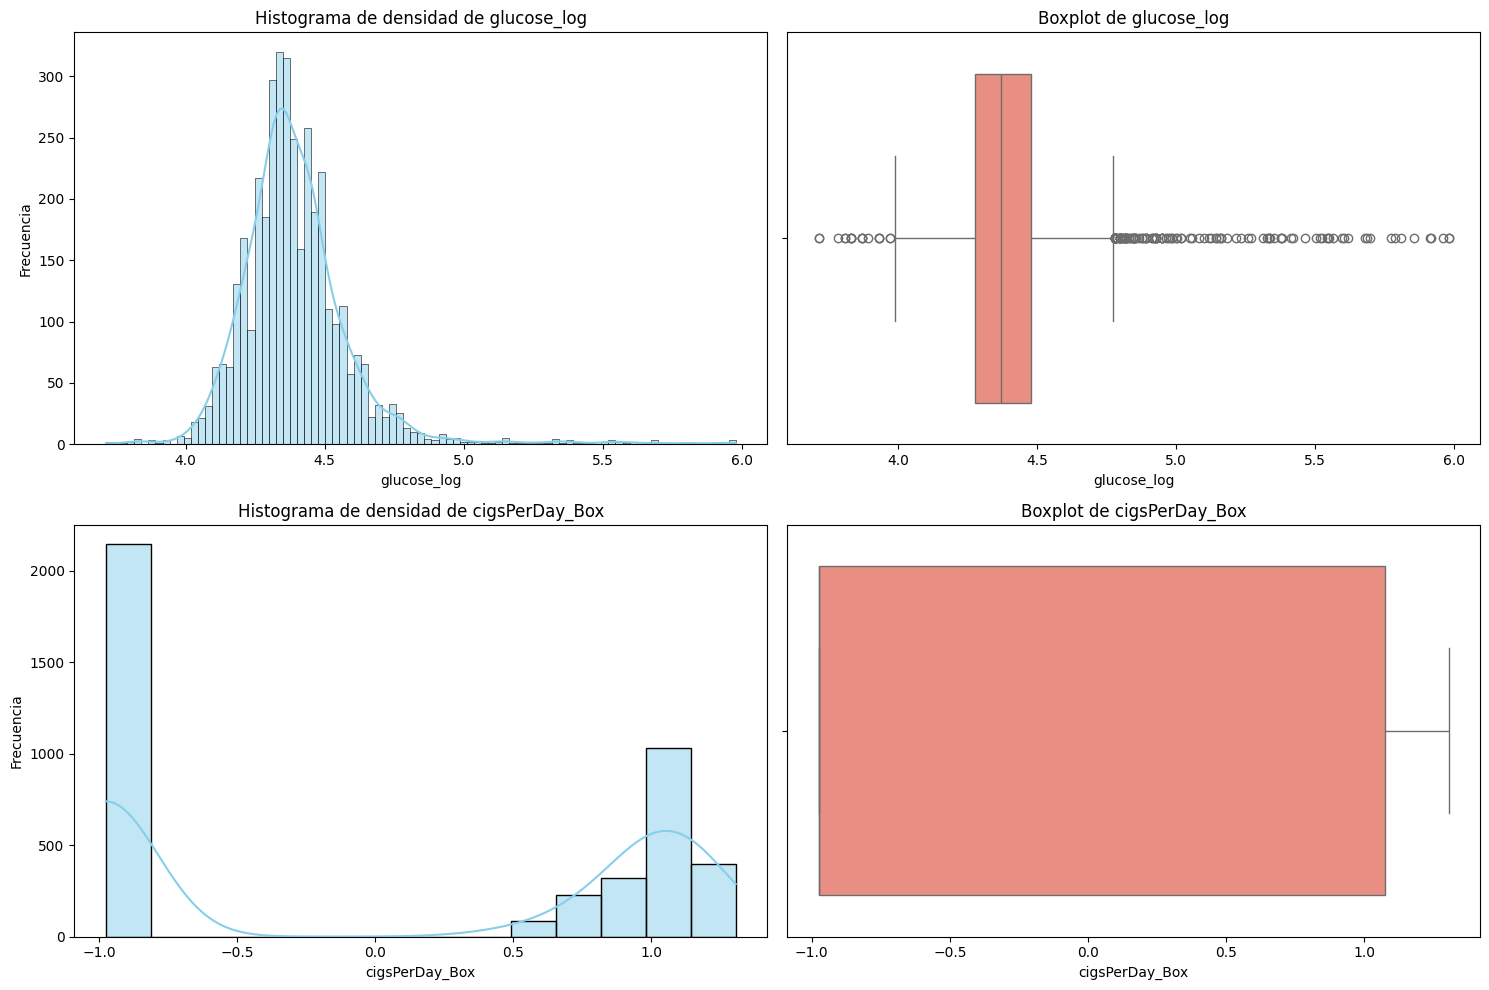

In [47]:
#Codigo corregido por la IA

cols_cambiados = ['glucose_log', 'cigsPerDay_Box']

nrows = len(cols_cambiados) # Dinámico, por si luego añades más columnas
fig, axes = plt.subplots(nrows=nrows, ncols=2, figsize=(15, 5*nrows))

for i, column in enumerate(cols_cambiados):
    # 1. Histograma de densidad (Izquierda)
    # CORRECCIÓN: Usamos df[column] para seleccionar solo la columna actual
    sns.histplot(df[column], kde=True, ax=axes[i,0], color="skyblue") 
    axes[i, 0].set_title(f'Histograma de densidad de {column}')
    axes[i, 0].set_xlabel(column)
    axes[i, 0].set_ylabel('Frecuencia')

    # 2. Boxplot (Derecha)
    # CORRECCIÓN: Usamos x=df[column]
    sns.boxplot(x=df[column], ax=axes[i,1], color="salmon")
    axes[i,1].set_title(f"Boxplot de {column}")
    axes[i,1].set_xlabel(column)

plt.tight_layout()
plt.show()

Aqui verificamos dos cosas:
1. El logaritmo para la variable **glucose** ha sido acertada, ya que al haber tantos outliers, impedía la visualización de la distribución al máximo. Es decir, que con la implementación del logaritmo podemos ver la distribución normal de manera más clara.
2. 